In [ ]:
import os
print(os.getcwd())

In [ ]:
import pandas as pd 
import numpy as np 
import math 


# load datasets


#loading each datasets and storing each of them individually

category_translation = pd.read_csv('category_translation.csv')

customers = pd.read_csv('customers.csv')

location = pd.read_csv('location.csv')

order_item = pd.read_csv('order_item.csv')

orders = pd.read_csv('orders.csv')

payments = pd.read_csv('payments.csv')

products = pd.read_csv('products.csv')

reviews = pd.read_csv('reviews.csv')

sellers = pd.read_csv('sellers.csv')








In [ ]:
#Observing each dataset individually checking for null values before combining them



# Category Translation 

category_translation.head() 
category_translation.info()
category_translation.describe()

#customer

customers.head()

#customers.info()

#customers.describe()




#location

#location.head()

#location.info()

#location.describe()





#order_item

order_item.head()

#order_item.isna().sum()

#order_item.info()




#orders 


orders.head()

#orders.info()

#orders.describe()

#orders.isna().sum()
#order_id is a foregin key





#payments

payments.head()

payments.info()

payments.describe()

payments.isnull().sum()






#products 

products.head()

# products.info()

# products.describe()

# products=products.dropna()

products.info()



#reviews 

reviews.head()

reviews.isna().sum()





#sellers 

sellers.head()

sellers.isna().sum()

In [18]:
# Merge customer details into orders using customer_id
df = pd.merge(orders, customers, "left", "customer_id")

# Merge product-level order details using order_id
df = pd.merge(df, order_item, "left", "order_id")

# Remove rows without valid order item information
df.dropna(subset=['order_item_id'], inplace=True)

# Add product information using product_id
df = pd.merge(df, products, "left", "product_id")

# Add payment information using order_id
df = pd.merge(df, payments, "left", "order_id")

# Remove rows with missing payment details
df.dropna(subset=['payment_sequential'], inplace=True)

# Check missing values after payment merge
df.isna().sum()

# Add customer reviews using order_id
df = pd.merge(df, reviews, "left", "order_id")

# Check missing values after review merge
df.isna().sum()

# Add seller information using seller_id
df = pd.merge(df, sellers, "left", "seller_id")

# Check missing values after seller merge
df.isna().sum()

# Translate product categories from Portuguese to English
df = pd.merge(df, category_translation, "left", "product_category_name")

# Final missing value check
df.isna().sum()

# Compare unique customers with total rows to identify duplicated rows after joins
print(abs(df["customer_id"].nunique() - df.shape[0]))

# Get column position of customer_unique_id
print(df.columns.get_loc('customer_unique_id'))

19642
8


In [19]:
# Feature Engineering

# Calculate total payment value for each order
df['total_order_value'] = df.groupby('order_id')['payment_value'].transform('sum')

# Convert timestamp columns into datetime format for time calculations
df['order_purchase_timestamp'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Calculate delivery duration
time_diff = df['order_delivered_customer_date'] - df['order_purchase_timestamp']

# Convert duration into readable format like "x days y hours"
df['total_duration'] = time_diff.apply(
    lambda x: f"{x.days} days {x.seconds//3600} hours"
    if pd.notna(x) else "Not Delivered"
)

# Count total items in each order
df['total_items_per_order'] = df.groupby('order_id')['order_id'].transform('count')

# Calculate how many unique orders each customer placed
df['customer_purchase_frequencey'] = df.groupby('customer_unique_id')['order_id'].transform('nunique')

# Calculate total money spent by each customer
df['customer_lifetime_value'] = (
    df.assign(total=df['price'] + df['freight_value'])
      .groupby('customer_unique_id')['total']
      .transform('sum')
)

# Calculate average purchase amount per customer
df['customer_avg_purchase'] = df.groupby('customer_unique_id')['price'].transform('mean')

# Display selected columns for checking created features
df.iloc[:, np.r_[8, -4:0]].head()

,customer_unique_id,total_items_per_order,customer_purchase_frequencey,customer_lifetime_value,customer_avg_purchase
0,7c396fd4830fd04220f754e42b4e5bff,3,2,160.24,31.34
1,7c396fd4830fd04220f754e42b4e5bff,3,2,160.24,31.34
2,7c396fd4830fd04220f754e42b4e5bff,3,2,160.24,31.34
3,af07308b275d755c9edb36a90c618231,1,1,141.46,118.70
4,3a653a41f6f9fc3d2a113cf8398680e8,1,1,179.12,159.90


In [22]:
# Exploratory Data Analysis

# Convert purchase timestamp into datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Rank customer orders based on purchase time
# First order = 1, second order = 2, etc.
df['order_rank'] = (
    df.sort_values('order_purchase_timestamp')
      .groupby('customer_unique_id')
      .cumcount() + 1
)

# Classify customers as New or Repeat
df['customer_type'] = np.where(df['order_rank'] == 1, 'New', 'Repeat')

# Calculate median customer lifetime value
median_amount_spent = df['customer_lifetime_value'].median()

# Segment customers into High Value and Low Value groups
df['customer_value'] = np.where(
    df['customer_lifetime_value'] > median_amount_spent,
    'High Value',
    'Low Value'
)

# Find customer distribution across states
state_dist = (
    df.groupby('customer_state')['customer_unique_id']
      .nunique()
      .sort_values(ascending=False)
)

# Display top states with highest customers
state_dist.head()

customer_state
SP    39980
RJ    12303
MG    11178
RS     5249
PR     4840
Name: customer_unique_id, dtype: int64

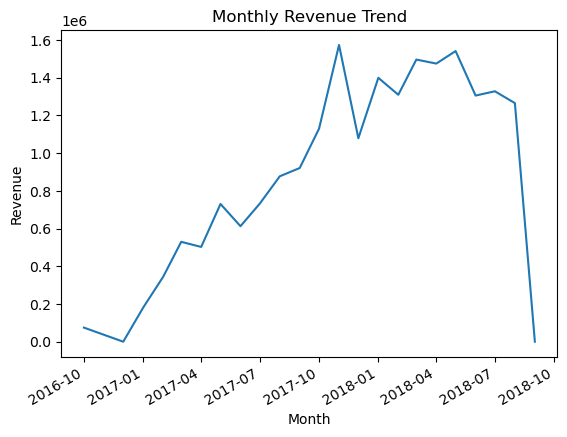

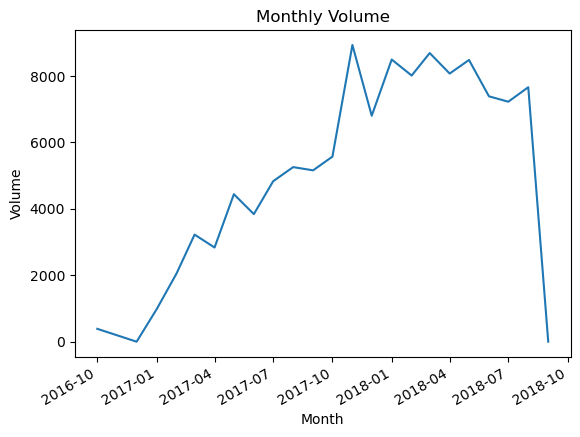

November 2017


In [21]:
# Create a monthly period column from purchase timestamp
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Calculate total monthly revenue
monthly_revenue = df.groupby('order_month')['payment_value'].sum()

# Sort months in correct chronological order
monthly_revenue = monthly_revenue.sort_index()

# Convert PeriodIndex into datetime format for plotting
monthly_revenue.index = monthly_revenue.index.to_timestamp()

# Plot monthly revenue trend
import matplotlib.pyplot as plt

monthly_revenue.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

# ------------------------------------------------------------

# Calculate total number of orders each month
order_volume = df.groupby('order_month')['order_id'].count()

# Sort months properly
order_volume = order_volume.sort_index()

# Convert index into timestamp format for visualization
order_volume.index = order_volume.index.to_timestamp()

# Plot monthly order volume trend
order_volume.plot()

plt.title('Monthly Volume')
plt.xlabel('Month')
plt.ylabel('Volume')

plt.show()

# ------------------------------------------------------------

# Find the month with highest revenue
peak = monthly_revenue.idxmax()

print(peak.month_name() + " " + str(peak.year))

bed_bath_table
product_category_name_english
agro_industry_and_commerce     118730.61
air_conditioning                91170.66
art                             30992.93
arts_and_craftmanship            2326.17
audio                           60388.62
                                 ...    
stationery                     318105.09
tablets_printing_image          10042.93
telephony                      487189.71
toys                           619975.71
watches_gifts                 1430553.48
Name: payment_value, Length: 71, dtype: float64


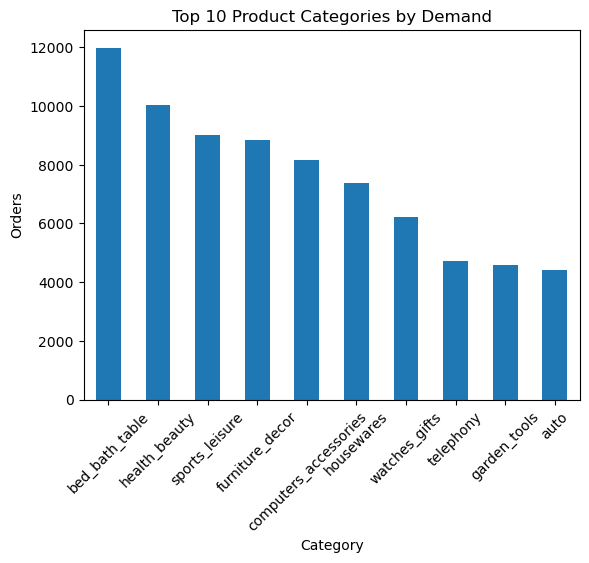

In [23]:
# Product Analysis

# Remove rows where product category is missing
# since category-level analysis needs valid categories
df = df.dropna(subset=['product_category_name_english'])

# Count number of products/orders in each category
# helps identify most popular category
category_sles = df.groupby('product_category_name_english')['product_category_name_english'].count()

# Print category with highest count
print(category_sles.idxmax())

# ------------------------------------------------------------

# Calculate total revenue generated by each category
revenue_each_category = df.groupby('product_category_name_english')['payment_value'].sum()

print(revenue_each_category)

# ------------------------------------------------------------

# Count total orders per category to measure demand
demand_dist = (
    df.groupby('product_category_name_english')['order_id']
      .count()
      .sort_values(ascending=False)
)

# Convert demand into percentage share
demand_pct = (demand_dist / demand_dist.sum()) * 100

# Create summary table for easier analysis
demand_summary = pd.DataFrame({
    'orders': demand_dist,
    'percentage': demand_pct
})

# Show top categories
demand_summary.head()

# ------------------------------------------------------------

# Visualize top 10 categories by demand
demand_dist.head(10).plot(kind='bar')

plt.title('Top 10 Product Categories by Demand')
plt.xlabel('Category')
plt.ylabel('Orders')
plt.xticks(rotation=45)

plt.show()

20156605


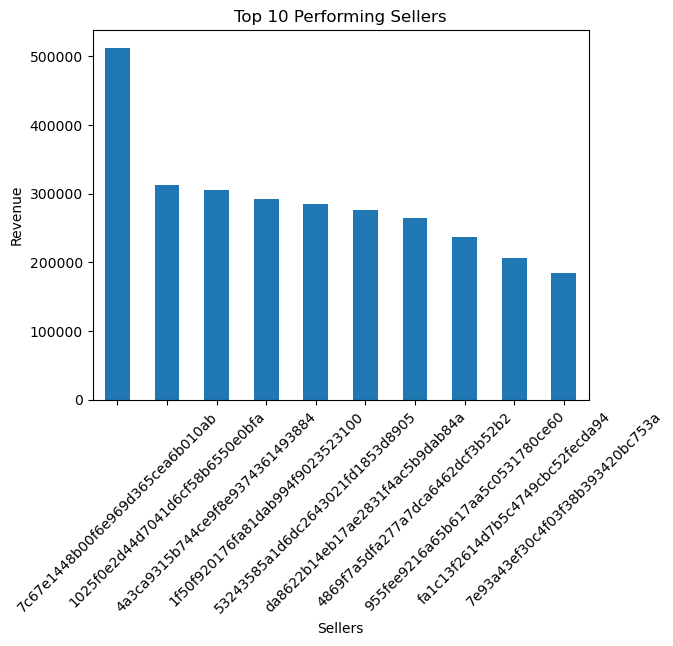

In [24]:
# Seller Analysis

# Calculate total revenue generated by each seller
highest_performing_seller = (
    df.groupby('seller_id')['payment_value']
      .sum()
      .sort_values(ascending=False)
      .astype(int)
)

# Display top 10 sellers by revenue
highest_performing_seller.head(10)

# ------------------------------------------------------------

# Calculate overall platform revenue
total_revenue = df['payment_value'].sum().astype(int)

print(total_revenue)

# ------------------------------------------------------------

# Calculate percentage contribution of each seller to total revenue
seller_distribution_in_revenue = (
    (highest_performing_seller / total_revenue) * 100
).astype(int)

# Display seller revenue contribution
seller_distribution_in_revenue.head()

# ------------------------------------------------------------

# Visualize top 10 sellers by revenue
highest_performing_seller.head(10).plot(kind='bar')

plt.title('Top 10 Performing Sellers')
plt.xlabel('Sellers')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()






In [27]:


# Extract number of days from total_duration column
days = (
    df['total_duration']
      .str.extract(r'(\d+)\s*days?')[0]
      .fillna(0)
      .astype(int)
)

# Extract number of hours from total_duration column
hours = (
    df['total_duration']
      .str.extract(r'(\d+)\s*hours?')[0]
      .fillna(0)
      .astype(int)
)

# Convert total duration into total hours
df['total_hours'] = days * 24 + hours

# ------------------------------------------------------------

# Calculate average delivery hours for each review score
review_distribution = (
    df.groupby('review_score')['total_hours']
      .agg('mean')
)

# Convert average hours back into days and hours format
days = (review_distribution // 24).astype(int)

hours = (review_distribution % 24).astype(int)

# Create readable delivery duration format
review_distribution_formatted = (
    days.astype(str) + ' days ' +
    hours.astype(str) + ' hours'
)

# Display formatted review distribution
review_distribution_formatted.head()


#Result 


print("Ratings and delievery time are directly proportional")
review_distribution_formatted.head()


Ratings and delievery time are directly proportional


review_score
1.0    16 days 21 hours
2.0    14 days 14 hours
3.0     13 days 7 hours
4.0    11 days 17 hours
5.0     10 days 4 hours
Name: total_hours, dtype: object

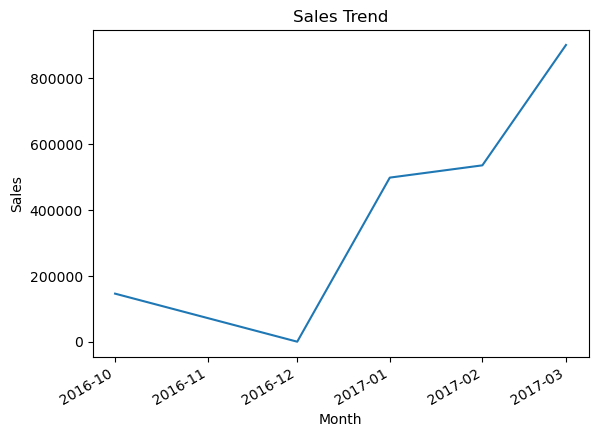

In [28]:
# Calculate total sales for each month
sales_trend = df.groupby('order_month')['total_order_value'].sum()

# Sort months in chronological order
sales_trend = sales_trend.sort_index()

# Convert PeriodIndex into datetime format for plotting
sales_trend.index = sales_trend.index.to_timestamp()

# Plot monthly sales trend
sales_trend.head().plot()

plt.title('Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

# Optional: show selected months only for cleaner x-axis
# plt.xticks(
#     sales_trend.index[::2],
#     rotation=45
# )

plt.show()

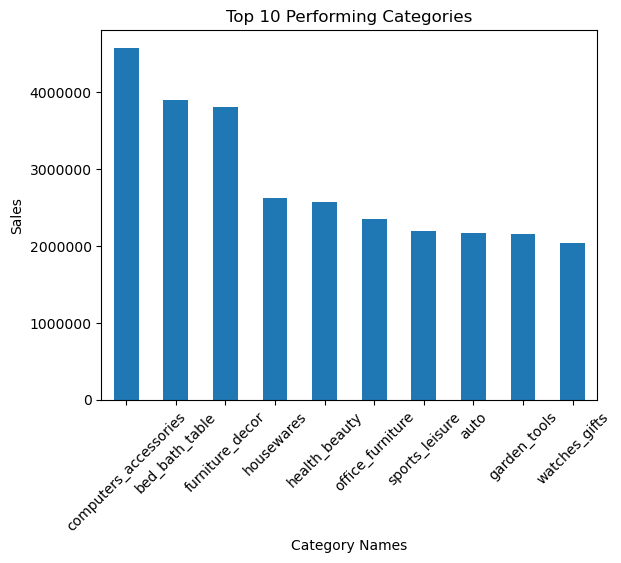

In [30]:
# Calculate total sales generated by each product category
category_sales = (
    df.groupby('product_category_name_english')['total_order_value']
      .sum()
      .sort_values(ascending=False)
      .astype(int)
)

# Display top 10 categories by sales
category_sales.head(10)

# Plot top 10 performing categories
category_sales.head(10).plot(kind='bar')

plt.title('Top 10 Performing Categories')
plt.xlabel('Category Names')
plt.ylabel('Sales')

# Show full numbers instead of scientific notation
plt.ticklabel_format(style='plain', axis='y')

# Rotate category labels for readability
plt.xticks(rotation=45)

plt.show()

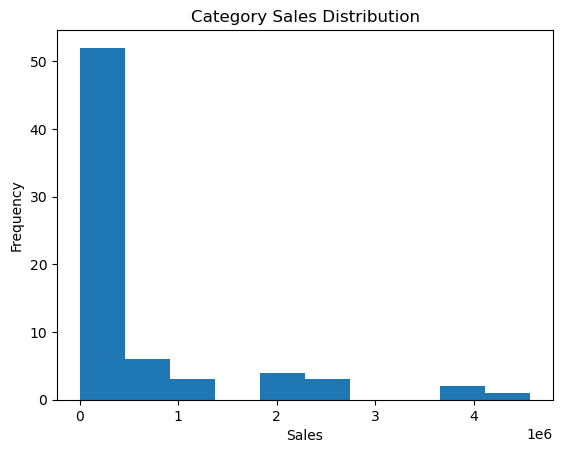

In [33]:
# Plot histogram of category sales

plt.hist(category_sales, bins=10)

plt.title('Category Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

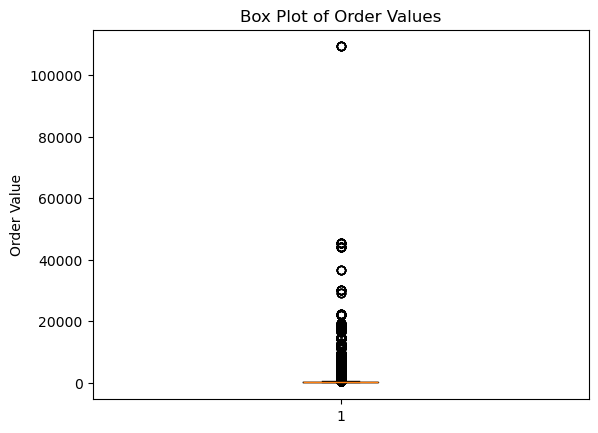

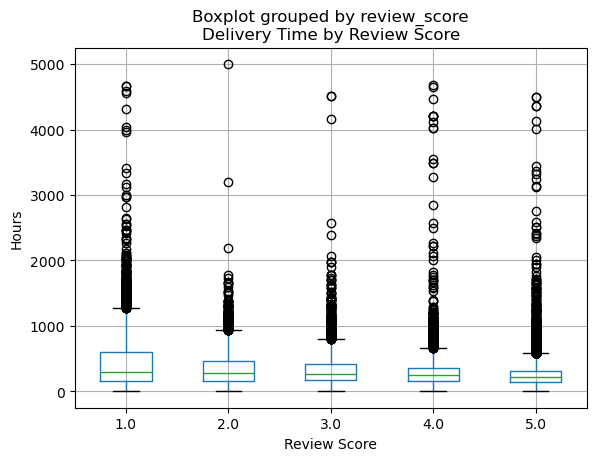

C:\Users\snows\AppData\Local\Temp\ipykernel_10336\3701078324.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(hours_bins)['total_order_value']


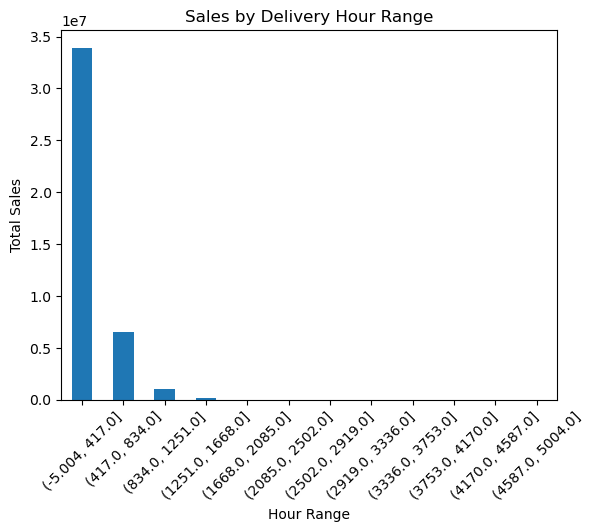

In [34]:
# Plot box plot for total order values

plt.boxplot(df['total_order_value'])

plt.title('Box Plot of Order Values')
plt.ylabel('Order Value')

plt.show()



# Plot delivery time distribution across review scores

df.boxplot(column='total_hours', by='review_score')

plt.title('Delivery Time by Review Score')

plt.xlabel('Review Score')
plt.ylabel('Hours')

plt.show()



# Create delivery time ranges using bins
hours_bins = pd.cut(
    df['total_hours'],
    bins=12
)

# Calculate total sales generated within each delivery time range
sales_by_hours = (
    df.groupby(hours_bins)['total_order_value']
      .sum()
)

# Display first few rows
sales_by_hours.head()



# Visualize sales generated across delivery time ranges
sales_by_hours.plot(kind='bar')

plt.title('Sales by Delivery Hour Range')
plt.xlabel('Hour Range')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()



# Insight:
# Helps understand whether certain delivery durations
# are associated with higher overall sales.